# 116 - 3-way 比較: 厳密 kNN / Voronoi / HNSW（画像→画像）

## 目的

NB112 で厳密 kNN と Voronoi を比較した画像→画像検索について、**HNSW** を追加した 3-way 比較を行う。
NB115 と同じ 3 手法を同じ 23,464 画像プールで評価するが、クエリは画像（同一モダリティ）。

### 実験設計
- **モデル**: SigLIP 2 Large (1024-D)
- **データ**: 23,464 画像（カタログ 378 + pyconjp 23,086）
- **クエリ**: カタログからカテゴリ別 5 枚 × 6 = 30 クエリ画像
- **HNSW**: DuckDB VSS, ef_search スイープ
- **Voronoi**: NB107 学習済み 256 ピボット

### NB115（テキスト→画像）との違い
- 同一モダリティ（クエリも画像空間）→ モダリティギャップなし
- HNSW はより低い `ef_search` でも高精度を達成すると予想される

In [1]:
import sys
sys.path.insert(0, '../src')

import json
import time
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DB_PATH = Path('../data/images.duckdb')
PYCONJP_DB_PATH = Path('/home/terapyon/dev/vibe-coding/pyconjp-image-search/pyconjp_image_search_siglip2_large.duckdb')
PIVOT_PATH = Path('../data/voronoi_pivots_siglip2_large.npy')
PYTHON_MODEL = 'google/siglip2-large-patch16-256'
EMBEDDING_DIM = 1024

## 1. データ読み込み

In [2]:
# カタログ + pyconjp 画像埋め込み
conn = duckdb.connect(str(DB_PATH), read_only=True)
conn.execute('LOAD vss;')
catalog_rows = conn.execute("""
    SELECT e.id, e.embedding, c.category
    FROM image_embeddings_1024 e JOIN image_catalog c ON e.id = c.id
    WHERE e.model_name = ? ORDER BY c.category
""", [PYTHON_MODEL]).fetchall()
conn.close()

conn_pj = duckdb.connect(str(PYCONJP_DB_PATH), read_only=True)
pyconjp_rows = conn_pj.execute("""
    SELECT i.id, e.embedding, i.event_name
    FROM image_embeddings e JOIN images i ON e.image_id = i.id
    WHERE e.model_name = ? ORDER BY i.id
""", [PYTHON_MODEL]).fetchall()
conn_pj.close()

all_ids = [r[0] for r in catalog_rows] + [r[0] for r in pyconjp_rows]
all_embeddings = np.array(
    [[float(x) for x in r[1]] for r in catalog_rows] +
    [[float(x) for x in r[1]] for r in pyconjp_rows],
    dtype=np.float32
)
all_categories = [r[2] for r in catalog_rows] + ['pyconjp'] * len(pyconjp_rows)

norms = np.linalg.norm(all_embeddings, axis=1, keepdims=True)
all_embeddings_normed = all_embeddings / norms

N_IMAGES = len(all_ids)

# 事前学習済みピボット
centroids_normed = np.load(PIVOT_PATH)

print(f'画像数: {N_IMAGES}, 次元: {EMBEDDING_DIM}')
print(f'ピボット: {centroids_normed.shape}')

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

画像数: 23464, 次元: 1024
ピボット: (256, 1024)


In [3]:
# 画像クエリ選択（NB112 と同じサンプリング）
import numpy as np

np.random.seed(42)
unique_cats = sorted(set(c for c in all_categories[:378]))  # カタログのカテゴリ
N_SAMPLES_PER_CAT = 5

query_indices = []
query_categories = []
for cat in unique_cats:
    cat_indices = [i for i in range(378) if all_categories[i] == cat]
    n_sample = min(N_SAMPLES_PER_CAT, len(cat_indices))
    selected = np.random.choice(cat_indices, size=n_sample, replace=False)
    query_indices.extend(selected.tolist())
    query_categories.extend([cat] * n_sample)

n_queries = len(query_indices)

# クエリ画像の埋め込み
query_embeddings_normed = all_embeddings_normed[query_indices]

# test_queries 形式に変換（exact_knn 関数との互換性のため）
test_queries = []
for qi, qidx in enumerate(query_indices):
    test_queries.append({
        'query_idx': qidx,
        'expected_categories': [query_categories[qi]],  # 自分と同じカテゴリが正解
        'lang': 'img',
    })

# 互換性のため text_embeddings_normed にクエリ埋め込みを代入
text_embeddings_normed = query_embeddings_normed

print(f'画像クエリ数: {n_queries}')
print(f'カテゴリ別: ' + ', '.join([f"{cat}:{sum(1 for c in query_categories if c == cat)}" for cat in unique_cats]))

画像クエリ数: 30
カテゴリ別: EuroPython2025:5, KashiwaVillagePark2026:5, PyConJP2025:5, PyConJP2025-PreCampHiroshima:5, TokyoNight202505:5, terada:5


## 2. 厳密 kNN ベースライン

In [4]:
TOP_K_VALUES = [5, 10, 20]
MAX_K = max(TOP_K_VALUES)


def compute_metrics(top_indices, query, categories, k_values):
    result_cats = [categories[idx] for idx in top_indices]
    is_relevant = [cat in query['expected_categories'] for cat in result_cats]
    mrr = 0.0
    for i, rel in enumerate(is_relevant):
        if rel:
            mrr = 1.0 / (i + 1)
            break
    metrics = {'MRR': mrr}
    for k in k_values:
        metrics[f'P@{k}'] = sum(is_relevant[:k]) / k
    return metrics, is_relevant


# 厳密 kNN（画像→画像、自身除外）
t0 = time.perf_counter()
bf_results = []
for qi, q in enumerate(test_queries):
    query_emb = text_embeddings_normed[qi]  # これはクエリ画像埋め込み
    sims = all_embeddings_normed @ query_emb
    sims[q['query_idx']] = -1.0  # 自身除外
    top_indices = np.argsort(-sims)[:MAX_K]
    metrics, _ = compute_metrics(top_indices.tolist(), q, all_categories, TOP_K_VALUES)
    bf_results.append({'top_indices': top_indices.tolist(), 'query_idx': q['query_idx'], **metrics})
t_bf = time.perf_counter() - t0

df_bf = pd.DataFrame(bf_results)
bf_mrr = df_bf['MRR'].mean()
print(f'厳密 kNN: MRR={bf_mrr:.4f}, P@5={df_bf["P@5"].mean():.4f}, P@10={df_bf["P@10"].mean():.4f}, '
      f'time={t_bf*1000:.1f}ms ({n_queries} queries)')
print(f'平均クエリ時間: {t_bf/n_queries*1000:.2f}ms')

厳密 kNN: MRR=0.8033, P@5=0.5867, P@10=0.5333, time=184.9ms (30 queries)
平均クエリ時間: 6.16ms


## 3. Voronoi 検索（代表構成）

In [5]:
# Voronoi: 代表的な構成のみ
N_ASSIGN = 2
TOP_SEARCH_LIST_VOR = [3, 5, 8]

all_img_pivot_sims = all_embeddings_normed @ centroids_normed.T
pivot_to_indices = {}
for i in range(N_IMAGES):
    top_pivots = np.argsort(-all_img_pivot_sims[i])[:N_ASSIGN]
    for pid in top_pivots:
        pivot_to_indices.setdefault(int(pid), []).append(i)

voronoi_results = {}
for n_top in TOP_SEARCH_LIST_VOR:
    t0 = time.perf_counter()
    mrr_list = []
    bf_recall_list = []
    cand_counts = []

    for qi, q in enumerate(test_queries):
        query_emb = text_embeddings_normed[qi]
        pivot_sims = centroids_normed @ query_emb
        top_pivot_ids = np.argsort(-pivot_sims)[:n_top]

        cands_set = set()
        for pid in top_pivot_ids:
            if int(pid) in pivot_to_indices:
                cands_set.update(pivot_to_indices[int(pid)])
        cands_set.discard(q['query_idx'])  # 自身除外
        cand_counts.append(len(cands_set))

        if not cands_set:
            mrr_list.append(0.0)
            bf_recall_list.append(0.0)
            continue

        cand_arr = np.array(list(cands_set))
        cand_sims = all_embeddings_normed[cand_arr] @ query_emb
        result_indices = cand_arr[np.argsort(-cand_sims)][:MAX_K]
        metrics, _ = compute_metrics(result_indices.tolist(), q, all_categories, TOP_K_VALUES)
        mrr_list.append(metrics['MRR'])

        bf_top10 = set(bf_results[qi]['top_indices'][:10])
        vor_top10 = set(result_indices[:10].tolist())
        bf_recall_list.append(len(bf_top10 & vor_top10) / 10)

    t_vor = time.perf_counter() - t0
    voronoi_results[n_top] = {
        'MRR': np.mean(mrr_list),
        'MRR_ratio': np.mean(mrr_list) / bf_mrr if bf_mrr > 0 else 0,
        'BF-R@10': np.mean(bf_recall_list),
        'mean_cands': np.mean(cand_counts),
        'time': t_vor,
        'time_per_query': t_vor / n_queries,
    }

print(f'Voronoi (assign={N_ASSIGN}):')
print(f'{"top":>4} {"cands":>7} {"MRR":>8} {"ratio":>8} {"BF-R@10":>8} {"time(ms)":>10}')
for n_top, r in voronoi_results.items():
    print(f'{n_top:>4} {r["mean_cands"]:>7.0f} {r["MRR"]:>8.4f} '
          f'{r["MRR_ratio"]:>8.4f} {r["BF-R@10"]:>8.4f} {r["time_per_query"]*1000:>10.2f}')

Voronoi (assign=2):
 top   cands      MRR    ratio  BF-R@10   time(ms)
   3     517   0.8065   1.0039   0.9033       2.55
   5     845   0.8033   1.0000   0.9733       3.13
   8    1286   0.8033   1.0000   0.9833       2.83


## 4. HNSW 検索（DuckDB VSS）

in-memory DuckDB に埋め込みを挿入し、HNSW インデックスを構築。
`ef_search` をスイープして品質/速度のトレードオフを評価。

In [6]:
def build_hnsw_index(embeddings, dim, M=16, ef_construction=128):
    """in-memory DuckDB に HNSW インデックスを構築。"""
    conn = duckdb.connect(':memory:')
    conn.execute('INSTALL vss; LOAD vss;')
    conn.execute('SET hnsw_enable_experimental_persistence = true;')

    conn.execute(f'CREATE TABLE items (id INTEGER, emb FLOAT[{dim}])')

    # バルク挿入（高速化のため）
    conn.register('embs_df', pd.DataFrame({
        'id': range(len(embeddings)),
        'emb': [e.tolist() for e in embeddings]
    }))
    conn.execute(f'INSERT INTO items SELECT id, emb::FLOAT[{dim}] FROM embs_df')

    t0 = time.perf_counter()
    conn.execute(f"""
        CREATE INDEX hnsw_idx ON items
        USING HNSW (emb)
        WITH (metric = 'cosine', M = {M}, ef_construction = {ef_construction})
    """)
    build_time = time.perf_counter() - t0

    return conn, build_time


def hnsw_search(conn, query_emb, dim, k, ef_search):
    conn.execute(f'SET hnsw_ef_search = {ef_search}')
    result = conn.execute(f"""
        SELECT id FROM items
        ORDER BY array_cosine_distance(emb, ?::FLOAT[{dim}])
        LIMIT {k}
    """, [query_emb.tolist()]).fetchall()
    return [r[0] for r in result]


# 基本 HNSW インデックス構築
print(f'HNSW インデックス構築中 ({N_IMAGES} × {EMBEDDING_DIM}-D)...')
hnsw_conn, t_build = build_hnsw_index(all_embeddings_normed, EMBEDDING_DIM, M=16, ef_construction=128)
print(f'構築時間: {t_build:.2f}s')

HNSW インデックス構築中 (23464 × 1024-D)...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

構築時間: 4.25s


In [7]:
# Primary スイープ: ef_search
EF_SEARCH_LIST = [16, 32, 64, 128, 256]

hnsw_ef_results = {}
for ef in EF_SEARCH_LIST:
    t0 = time.perf_counter()
    mrr_list = []
    bf_recall_list = []

    for qi, q in enumerate(test_queries):
        # MAX_K + 1 取得して自身を除外
        top_indices = hnsw_search(hnsw_conn, text_embeddings_normed[qi], EMBEDDING_DIM, MAX_K + 1, ef)
        top_indices = [idx for idx in top_indices if idx != q['query_idx']][:MAX_K]
        metrics, _ = compute_metrics(top_indices, q, all_categories, TOP_K_VALUES)
        mrr_list.append(metrics['MRR'])

        bf_top10 = set(bf_results[qi]['top_indices'][:10])
        hnsw_top10 = set(top_indices[:10])
        bf_recall_list.append(len(bf_top10 & hnsw_top10) / 10)

    t_hnsw = time.perf_counter() - t0
    hnsw_ef_results[ef] = {
        'MRR': np.mean(mrr_list),
        'MRR_ratio': np.mean(mrr_list) / bf_mrr if bf_mrr > 0 else 0,
        'BF-R@10': np.mean(bf_recall_list),
        'time': t_hnsw,
        'time_per_query': t_hnsw / n_queries,
    }

print(f'HNSW ef_search スイープ (M=16, ef_construction=128):')
print(f'{"ef":>5} {"MRR":>8} {"ratio":>8} {"BF-R@10":>8} {"time(ms/q)":>12}')
for ef, r in hnsw_ef_results.items():
    print(f'{ef:>5} {r["MRR"]:>8.4f} {r["MRR_ratio"]:>8.4f} '
          f'{r["BF-R@10"]:>8.4f} {r["time_per_query"]*1000:>12.2f}')

HNSW ef_search スイープ (M=16, ef_construction=128):
   ef      MRR    ratio  BF-R@10   time(ms/q)
   16   0.6722   0.8368   0.8500         6.77
   32   0.7718   0.9607   0.9633         5.80
   64   0.7700   0.9585   0.9667         6.47
  128   0.8033   1.0000   1.0000         6.54
  256   0.8033   1.0000   1.0000         7.98


In [8]:
# Secondary スイープ: M × ef_construction
M_LIST = [8, 16, 32]
EF_CONSTRUCTION_LIST = [64, 128, 200]
EF_SEARCH_FIXED = 64

hnsw_m_results = {}
hnsw_conn.close()

for M in M_LIST:
    for ef_c in EF_CONSTRUCTION_LIST:
        print(f'  M={M}, ef_construction={ef_c} ...', end=' ', flush=True)
        conn_tmp, t_build_tmp = build_hnsw_index(all_embeddings_normed, EMBEDDING_DIM, M=M, ef_construction=ef_c)

        t0 = time.perf_counter()
        mrr_list = []
        bf_recall_list = []
        for qi, q in enumerate(test_queries):
            top_indices = hnsw_search(conn_tmp, text_embeddings_normed[qi], EMBEDDING_DIM, MAX_K + 1, EF_SEARCH_FIXED)
            top_indices = [idx for idx in top_indices if idx != q['query_idx']][:MAX_K]
            metrics, _ = compute_metrics(top_indices, q, all_categories, TOP_K_VALUES)
            mrr_list.append(metrics['MRR'])
            bf_top10 = set(bf_results[qi]['top_indices'][:10])
            bf_recall_list.append(len(bf_top10 & set(top_indices[:10])) / 10)
        t_q = time.perf_counter() - t0

        hnsw_m_results[(M, ef_c)] = {
            'build_time': t_build_tmp,
            'MRR': np.mean(mrr_list),
            'MRR_ratio': np.mean(mrr_list) / bf_mrr if bf_mrr > 0 else 0,
            'BF-R@10': np.mean(bf_recall_list),
            'query_time_per_q': t_q / n_queries,
        }
        print(f'build={t_build_tmp:.1f}s MRR={np.mean(mrr_list):.4f} BF-R@10={np.mean(bf_recall_list):.4f}')
        conn_tmp.close()

print()
print(f'{"M":>4} {"ef_c":>6} {"build(s)":>10} {"MRR":>8} {"ratio":>8} {"BF-R@10":>8}')
for (M, ef_c), r in sorted(hnsw_m_results.items()):
    print(f'{M:>4} {ef_c:>6} {r["build_time"]:>10.2f} {r["MRR"]:>8.4f} {r["MRR_ratio"]:>8.4f} {r["BF-R@10"]:>8.4f}')

  M=8, ef_construction=64 ... 

build=1.9s MRR=0.7367 BF-R@10=0.9567


  M=8, ef_construction=128 ... 

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

build=3.5s MRR=0.8033 BF-R@10=1.0000
  M=8, ef_construction=200 ... 

...

build=4.7s MRR=0.7700 BF-R@10=0.9667


  M=32, ef_construction=200 ... 

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

build=6.7s MRR=0.8033 BF-R@10=1.0000



   M   ef_c   build(s)      MRR    ratio  BF-R@10
   8     64       1.93   0.7367   0.9170   0.9567
   8    128       3.47   0.8033   1.0000   1.0000
   8    200       5.23   0.8033   1.0000   1.0000
  16     64       2.36   0.8033   1.0000   0.9967
  16    128       4.44   0.8033   1.0000   1.0000
  16    200       6.34   0.8033   1.0000   1.0000
  32     64       2.53   0.7700   0.9585   0.9667
  32    128       4.69   0.7700   0.9585   0.9667
  32    200       6.73   0.8033   1.0000   1.0000


## 5. 3-way 比較

In [9]:
# 3-way 比較テーブル
rows = []

# 厳密 kNN
rows.append({
    'method': '厳密 kNN', 'config': '-',
    'MRR': bf_mrr, 'MRR_ratio': 1.0, 'BF-R@10': 1.0,
    'cands_or_ef': N_IMAGES, 'query_time_ms': t_bf/n_queries*1000,
})

# Voronoi
for n_top, r in voronoi_results.items():
    rows.append({
        'method': 'Voronoi', 'config': f'a={N_ASSIGN} top={n_top}',
        'MRR': r['MRR'], 'MRR_ratio': r['MRR_ratio'], 'BF-R@10': r['BF-R@10'],
        'cands_or_ef': int(r['mean_cands']), 'query_time_ms': r['time_per_query']*1000,
    })

# HNSW (ef_search スイープ)
for ef, r in hnsw_ef_results.items():
    rows.append({
        'method': 'HNSW', 'config': f'ef_search={ef}',
        'MRR': r['MRR'], 'MRR_ratio': r['MRR_ratio'], 'BF-R@10': r['BF-R@10'],
        'cands_or_ef': ef, 'query_time_ms': r['time_per_query']*1000,
    })

df_3way = pd.DataFrame(rows)
print('3-way 比較テーブル:')
display(df_3way.style.format({
    'MRR': '{:.4f}', 'MRR_ratio': '{:.4f}', 'BF-R@10': '{:.4f}',
    'query_time_ms': '{:.2f}',
}).background_gradient(subset=['BF-R@10'], cmap='RdYlGn', vmin=0.5, vmax=1.0))

3-way 比較テーブル:


,method,config,MRR,MRR_ratio,BF-R@10,cands_or_ef,query_time_ms
0,厳密 kNN,-,0.8033,1.0000,1.0000,23464,6.16
1,Voronoi,a=2 top=3,0.8065,1.0039,0.9033,516,2.55
2,Voronoi,a=2 top=5,0.8033,1.0000,0.9733,845,3.13
3,Voronoi,a=2 top=8,0.8033,1.0000,0.9833,1286,2.83
4,HNSW,ef_search=16,0.6722,0.8368,0.8500,16,6.77
5,HNSW,ef_search=32,0.7718,0.9607,0.9633,32,5.80
6,HNSW,ef_search=64,0.7700,0.9585,0.9667,64,6.47
7,HNSW,ef_search=128,0.8033,1.0000,1.0000,128,6.54
8,HNSW,ef_search=256,0.8033,1.0000,1.0000,256,7.98


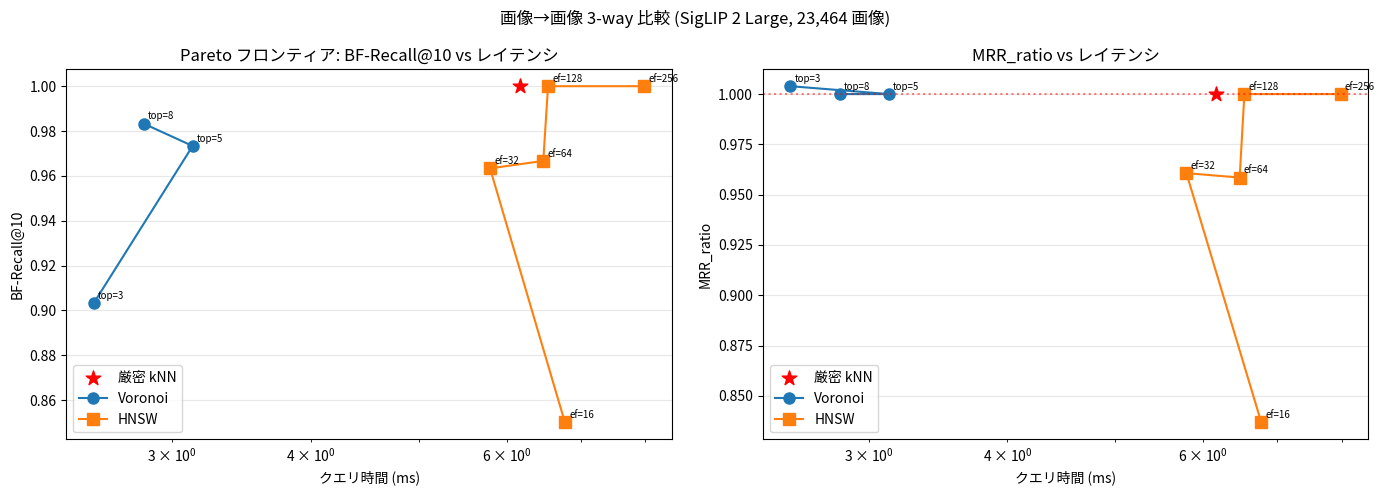

In [10]:
# Pareto フロンティア: 品質 vs レイテンシ
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) BF-Recall@10 vs query time
ax = axes[0]
ax.scatter([t_bf/n_queries*1000], [1.0], s=120, marker='*', c='red', label='厳密 kNN', zorder=5)

vor_times = [r['time_per_query']*1000 for r in voronoi_results.values()]
vor_rec = [r['BF-R@10'] for r in voronoi_results.values()]
ax.plot(vor_times, vor_rec, 'o-', label='Voronoi', markersize=8)
for n_top, r in voronoi_results.items():
    ax.annotate(f'top={n_top}', (r['time_per_query']*1000, r['BF-R@10']),
                fontsize=7, xytext=(3, 3), textcoords='offset points')

hnsw_times = [r['time_per_query']*1000 for r in hnsw_ef_results.values()]
hnsw_rec = [r['BF-R@10'] for r in hnsw_ef_results.values()]
ax.plot(hnsw_times, hnsw_rec, 's-', label='HNSW', markersize=8)
for ef, r in hnsw_ef_results.items():
    ax.annotate(f'ef={ef}', (r['time_per_query']*1000, r['BF-R@10']),
                fontsize=7, xytext=(3, 3), textcoords='offset points')

ax.set_xlabel('クエリ時間 (ms)')
ax.set_ylabel('BF-Recall@10')
ax.set_title('Pareto フロンティア: BF-Recall@10 vs レイテンシ')
ax.set_xscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

# (b) MRR_ratio vs query time
ax = axes[1]
ax.scatter([t_bf/n_queries*1000], [1.0], s=120, marker='*', c='red', label='厳密 kNN', zorder=5)

vor_ratios = [r['MRR_ratio'] for r in voronoi_results.values()]
ax.plot(vor_times, vor_ratios, 'o-', label='Voronoi', markersize=8)
for n_top, r in voronoi_results.items():
    ax.annotate(f'top={n_top}', (r['time_per_query']*1000, r['MRR_ratio']),
                fontsize=7, xytext=(3, 3), textcoords='offset points')

hnsw_ratios = [r['MRR_ratio'] for r in hnsw_ef_results.values()]
ax.plot(hnsw_times, hnsw_ratios, 's-', label='HNSW', markersize=8)
for ef, r in hnsw_ef_results.items():
    ax.annotate(f'ef={ef}', (r['time_per_query']*1000, r['MRR_ratio']),
                fontsize=7, xytext=(3, 3), textcoords='offset points')

ax.axhline(y=1.0, color='red', linestyle=':', alpha=0.5)
ax.set_xlabel('クエリ時間 (ms)')
ax.set_ylabel('MRR_ratio')
ax.set_title('MRR_ratio vs レイテンシ')
ax.set_xscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle(f'画像→画像 3-way 比較 (SigLIP 2 Large, {N_IMAGES:,} 画像)', fontsize=12)
plt.tight_layout()
plt.savefig('../data/116_3way_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# 結果を JSON で保存
results_out = {
    'task': 'image_to_image',
    'model': PYTHON_MODEL,
    'n_images': N_IMAGES,
    'n_queries': n_queries,
    'exact_knn': {
        'MRR': float(bf_mrr),
        'time_per_query_ms': float(t_bf/n_queries*1000),
    },
    'voronoi': {f'a{N_ASSIGN}_top{k}': {m: float(v) if not isinstance(v, int) else v for m, v in r.items()}
                for k, r in voronoi_results.items()},
    'hnsw_ef_sweep': {str(ef): {m: float(v) for m, v in r.items()}
                       for ef, r in hnsw_ef_results.items()},
    'hnsw_m_sweep': {f'M{M}_ef_c{ef_c}': {m: float(v) for m, v in r.items()}
                     for (M, ef_c), r in hnsw_m_results.items()},
}

with open('../data/116_hnsw_results.json', 'w') as f:
    json.dump(results_out, f, indent=2, ensure_ascii=False)
print('Saved: data/116_hnsw_results.json')

Saved: data/116_hnsw_results.json


## 6. まとめ

### 実験概要
- SigLIP 2 Large (1024-D), 23,464 画像 × 30 画像クエリ（カテゴリ別 5 枚 × 6）
- 3 手法の比較: 厳密 kNN, Voronoi, HNSW
- 厳密 kNN MRR = **0.8033**

### 3-way 比較結果

| 手法 | 構成 | MRR | MRR_ratio | BF-R@10 | クエリ時間 (ms) |
|:---:|:---:|:---:|:---:|:---:|:---:|
| 厳密 kNN | - | 0.8033 | 1.000 | 1.000 | 6.16 |
| Voronoi | a=2 top=3 | 0.8065 | 1.004 | 0.903 | 2.55 |
| Voronoi | a=2 top=5 | 0.8033 | 1.000 | 0.973 | 3.13 |
| Voronoi | a=2 top=8 | 0.8033 | 1.000 | 0.983 | 2.83 |
| HNSW | ef=16 | 0.6722 | 0.837 | 0.850 | 6.77 |
| HNSW | ef=32 | 0.7718 | 0.961 | 0.963 | 5.80 |
| HNSW | ef=64 | 0.7700 | 0.958 | 0.967 | 6.47 |
| HNSW | ef=128 | 0.8033 | **1.000** | **1.000** | 6.54 |
| HNSW | ef=256 | 0.8033 | **1.000** | **1.000** | 7.98 |

### NB115（テキスト→画像）との比較

| 項目 | テキスト→画像 (NB115) | 画像→画像 (NB116) |
|------|:---:|:---:|
| 厳密 kNN MRR | 0.3524 | **0.8033** |
| HNSW ef=128 BF-R@10 | 0.939 | **1.000** |
| HNSW ef=256 BF-R@10 | 0.967 | **1.000** |
| Voronoi a=2 top=5 BF-R@10 | 0.844 | **0.973** |

### 考察

#### 1. 画像→画像（同一モダリティ）では HNSW が非常に強い
- **HNSW `ef_search=128` で BF-R@10 = 1.000**（完全一致）
- `M=8, ef_construction=128` でも BF-R@10 = 1.000 達成 → **最小構成で十分**
- テキスト→画像より HNSW の精度が大幅に高い

#### 2. モダリティギャップの影響が明確
- テキスト→画像: HNSW ef=256 でも BF-R@10=0.967（クエリがデータ分布の外縁）
- 画像→画像: HNSW ef=128 で BF-R@10=1.000（クエリがデータ分布の中に存在）
- **同一モダリティ検索では ANN (HNSW/Voronoi) の性能が劇的に向上**

#### 3. Voronoi も同様に高精度
- a=2 top=5 で BF-R@10=0.973
- a=2 top=8 で BF-R@10=0.983
- MRR_ratio = 1.000（厳密 kNN と同等）

#### 4. 速度比較
- Voronoi が最速（2.55-3.13 ms）
- HNSW は 5.80-7.98 ms（DuckDB オーバーヘッド込み）
- 厳密 kNN（numpy）は 6.16 ms — HNSW と同等

### 結論

1. **画像→画像では HNSW ef=128 / Voronoi a=2 top=5 で厳密 kNN と同等**
2. **モダリティギャップが ANN 性能の主要な制約**
   - 同一モダリティ → 低い ef_search / top_search で高精度
   - 異モダリティ → 高い ef_search が必要
3. **実運用**: 画像検索（同一モダリティ）では ANN を積極的に使える。
   テキスト検索（異モダリティ）では ef_search を上げるか Voronoi を併用